# 333 piezas del cerebro: el atlas que está reescribiendo cómo medimos lo que hay dentro

**5 cerebros. 10.000 secciones histológicas. 333 regiones delimitadas a mano.**

¿Cuántos pedazos distintos tiene tu cerebro? Depende de a quién le preguntes. Hasta ahora, los atlas más usados en neuroimagen tenían entre 14 y unas pocas docenas de regiones grandes. NextBrain las descompone en 333.

> **Paper**: Iglesias et al. (2025). *A probabilistic histological atlas of the human brain for MRI segmentation*. **Nature**.  > **DOI**: [10.1038/s41586-025-09708-2](https://doi.org/10.1038/s41586-025-09708-2)  > **Video**: [Ver en YouTube](https://youtube.com/shorts/N0jvqX4wV6o)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-11-05-nextbrain-atlas-333-regiones/notebook.ipynb)

## Qué hicieron

El equipo (UCL + MGH/Harvard) seccionó cinco hemisferios cerebrales completos en aproximadamente 10.000 láminas histológicas, las alineó en 3D con métodos de IA y delineó manualmente 333 regiones de interés (la versión simplificada agrupa en 264). Después construyeron una herramienta probabilística (bayesiana) que segmenta esas mismas regiones automáticamente en resonancias magnéticas (MRI) clínicas.

El paper presenta dos aplicaciones: segmentación de MRI ex vivo de altísima resolución y, más interesante para nosotros, distinguir cerebros con Alzheimer de controles en datos clínicos reales (ADNI, n = 383).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Iglesias et al. (2025), Nature | doi:10.1038/s41586-025-09708-2'
COLOR_NUEVO = '#2563EB'      # NextBrain (azul CaM)
COLOR_PREVIO = '#BBBBBB'     # Pipeline anterior / baseline
COLOR_ALERTA = '#DC2626'     # Mejor método / línea de referencia
COLOR_REFERENCIA = '#D97706' # Allen MNI / valor intermedio

# ── Imports + estilo ──
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ── Carga de datos ──
registro = pd.read_csv('datos/registro_casos_mm.csv')
auroc = pd.read_csv('datos/auroc_alzheimer.csv')
dice = pd.read_csv('datos/dice_mediana.csv')

print(f'Registro 3D: {len(registro)} filas ({registro["caso"].nunique()} casos x {registro["metodo"].nunique()} metodos)')
print(f'AUROC Alzheimer: {len(auroc)} metodos')
print(f'Dice mediana: {len(dice)} resoluciones')
print()
print('Vista previa registro:')
print(registro.head(4).to_string(index=False))

Registro 3D: 10 filas (5 casos x 2 metodos)
AUROC Alzheimer: 3 metodos
Dice mediana: 2 resoluciones

Vista previa registro:
  caso metodo  error_mm_media  error_mm_sd  p_wilcoxon_caso
Caso 1  nueva            1.27         0.59         0.000880
Caso 1 previa            1.42         0.72         0.000880
Caso 2  nueva            0.98         0.55         0.000056
Caso 2 previa            1.49         0.65         0.000056


## Aquí está.

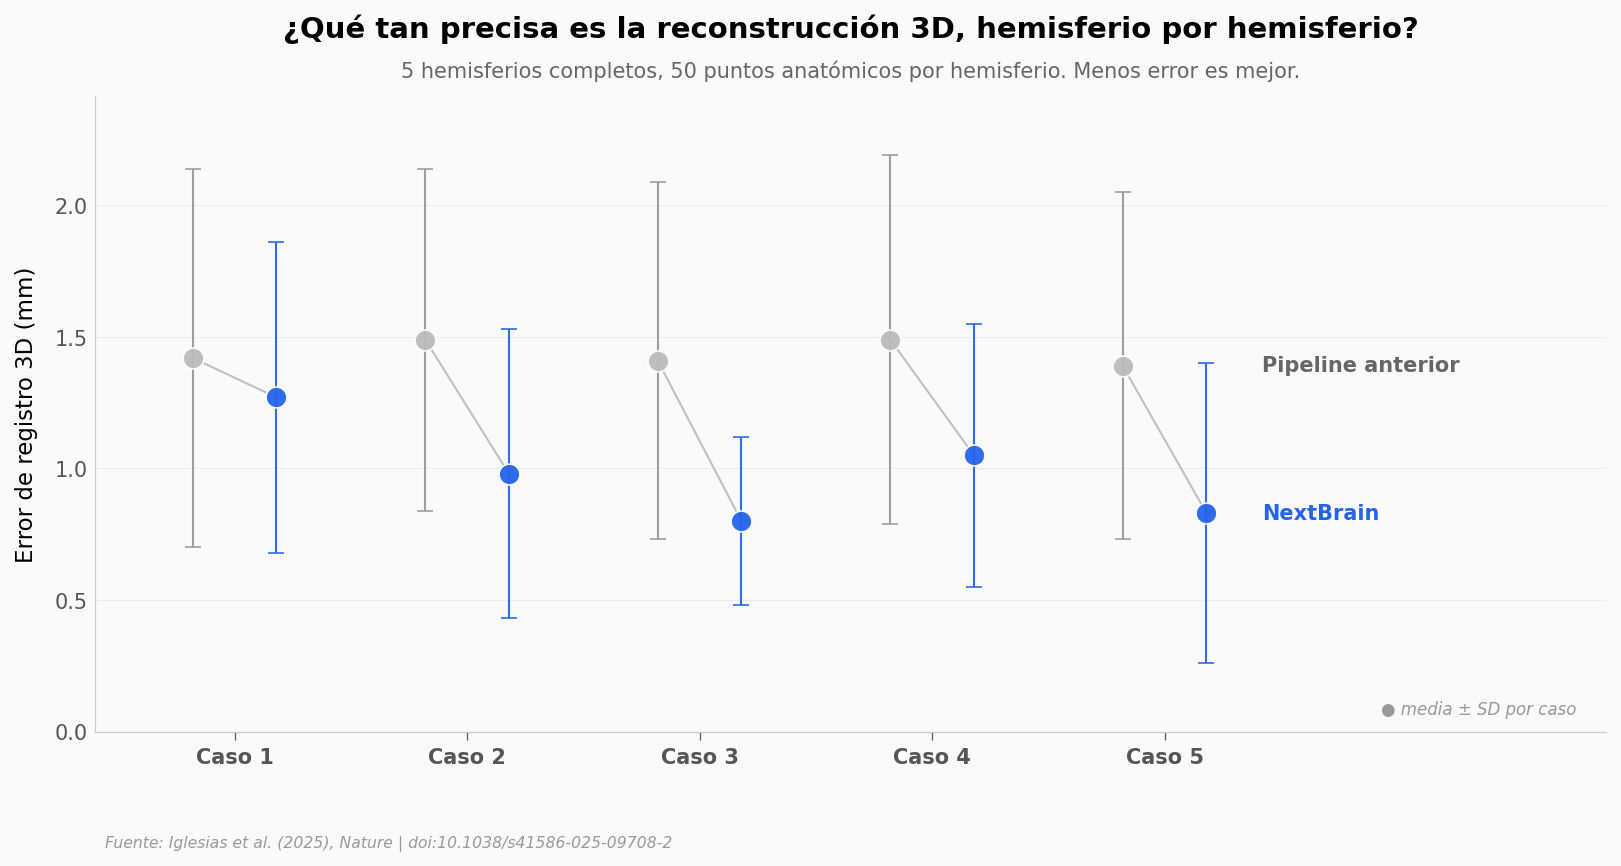

In [2]:
# Hero: error de registro 3D por caso, pipeline anterior vs NextBrain
fig, ax = plt.subplots(figsize=(13, 5.5))

casos = registro['caso'].unique().tolist()
x_pos = np.arange(len(casos))

err_previa = registro[registro['metodo'] == 'previa'].set_index('caso').loc[casos, 'error_mm_media'].values
err_nueva  = registro[registro['metodo'] == 'nueva' ].set_index('caso').loc[casos, 'error_mm_media'].values
sd_previa  = registro[registro['metodo'] == 'previa'].set_index('caso').loc[casos, 'error_mm_sd'].values
sd_nueva   = registro[registro['metodo'] == 'nueva' ].set_index('caso').loc[casos, 'error_mm_sd'].values

# Lineas pareadas (ladder) entre previa y nueva por caso
for i, c in enumerate(casos):
    ax.plot([i - 0.18, i + 0.18], [err_previa[i], err_nueva[i]],
            color='#999999', linewidth=1.0, alpha=0.6, zorder=2)

# Puntos previa con barra de error (SD)
ax.errorbar(x_pos - 0.18, err_previa, yerr=sd_previa, fmt='o',
            color=COLOR_PREVIO, markersize=10, capsize=4, capthick=1.2,
            markeredgecolor='white', markeredgewidth=0.8, zorder=4,
            ecolor='#999999', elinewidth=1.0, alpha=0.95)

# Puntos nueva con barra de error (SD)
ax.errorbar(x_pos + 0.18, err_nueva, yerr=sd_nueva, fmt='o',
            color=COLOR_NUEVO, markersize=10, capsize=4, capthick=1.2,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5,
            ecolor=COLOR_NUEVO, elinewidth=1.0, alpha=0.95)

# Etiquetas inline (reemplazan legend box)
ax.text(x_pos[-1] + 0.42, err_previa[-1], 'Pipeline anterior',
        fontsize=10, color='#666666', fontweight='bold', va='center')
ax.text(x_pos[-1] + 0.42, err_nueva[-1], 'NextBrain',
        fontsize=10, color=COLOR_NUEVO, fontweight='bold', va='center')

ax.set_xticks(x_pos)
ax.set_xticklabels(casos, fontsize=10, fontweight='bold')
ax.set_ylabel('Error de registro 3D (mm)', fontsize=11)
ax.set_xlim(-0.6, len(casos) - 0.3 + 1.2)
ax.set_ylim(0, max(err_previa.max() + sd_previa.max(), 2.3) * 1.05)

ax.set_title('¿Qué tan precisa es la reconstrucción 3D, hemisferio por hemisferio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '5 hemisferios completos, 50 puntos anatómicos por hemisferio. Menos error es mejor.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '● media ± SD por caso', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/registro_pareado.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** los cinco hemisferios se mueven en la misma dirección. No hay un caso donde la pipeline anterior gane. La media baja de 1,44 mm a 0,99 mm — un 31% menos error en la posición de los puntos anatómicos de referencia. El paper reporta un test pareado de Wilcoxon sobre los 250 puntos individuales con p = 4 × 10⁻²².

Una mejora consistente en cinco hemisferios distintos es más informativa que una mejora promedio: dice que el método nuevo no depende de las particularidades de un cerebro específico.

## Zoom: ¿sirve para algo clínicamente útil?

Una herramienta de segmentación se prueba pidiéndole que distinga cerebros sanos de cerebros con enfermedad. El equipo corrió NextBrain sobre 383 escáneres del consorcio ADNI (168 con Alzheimer, 215 controles), y comparó la clasificación con dos referentes: FreeSurfer 7.0 (la herramienta estándar de la última década) y el atlas histológico Allen MNI.

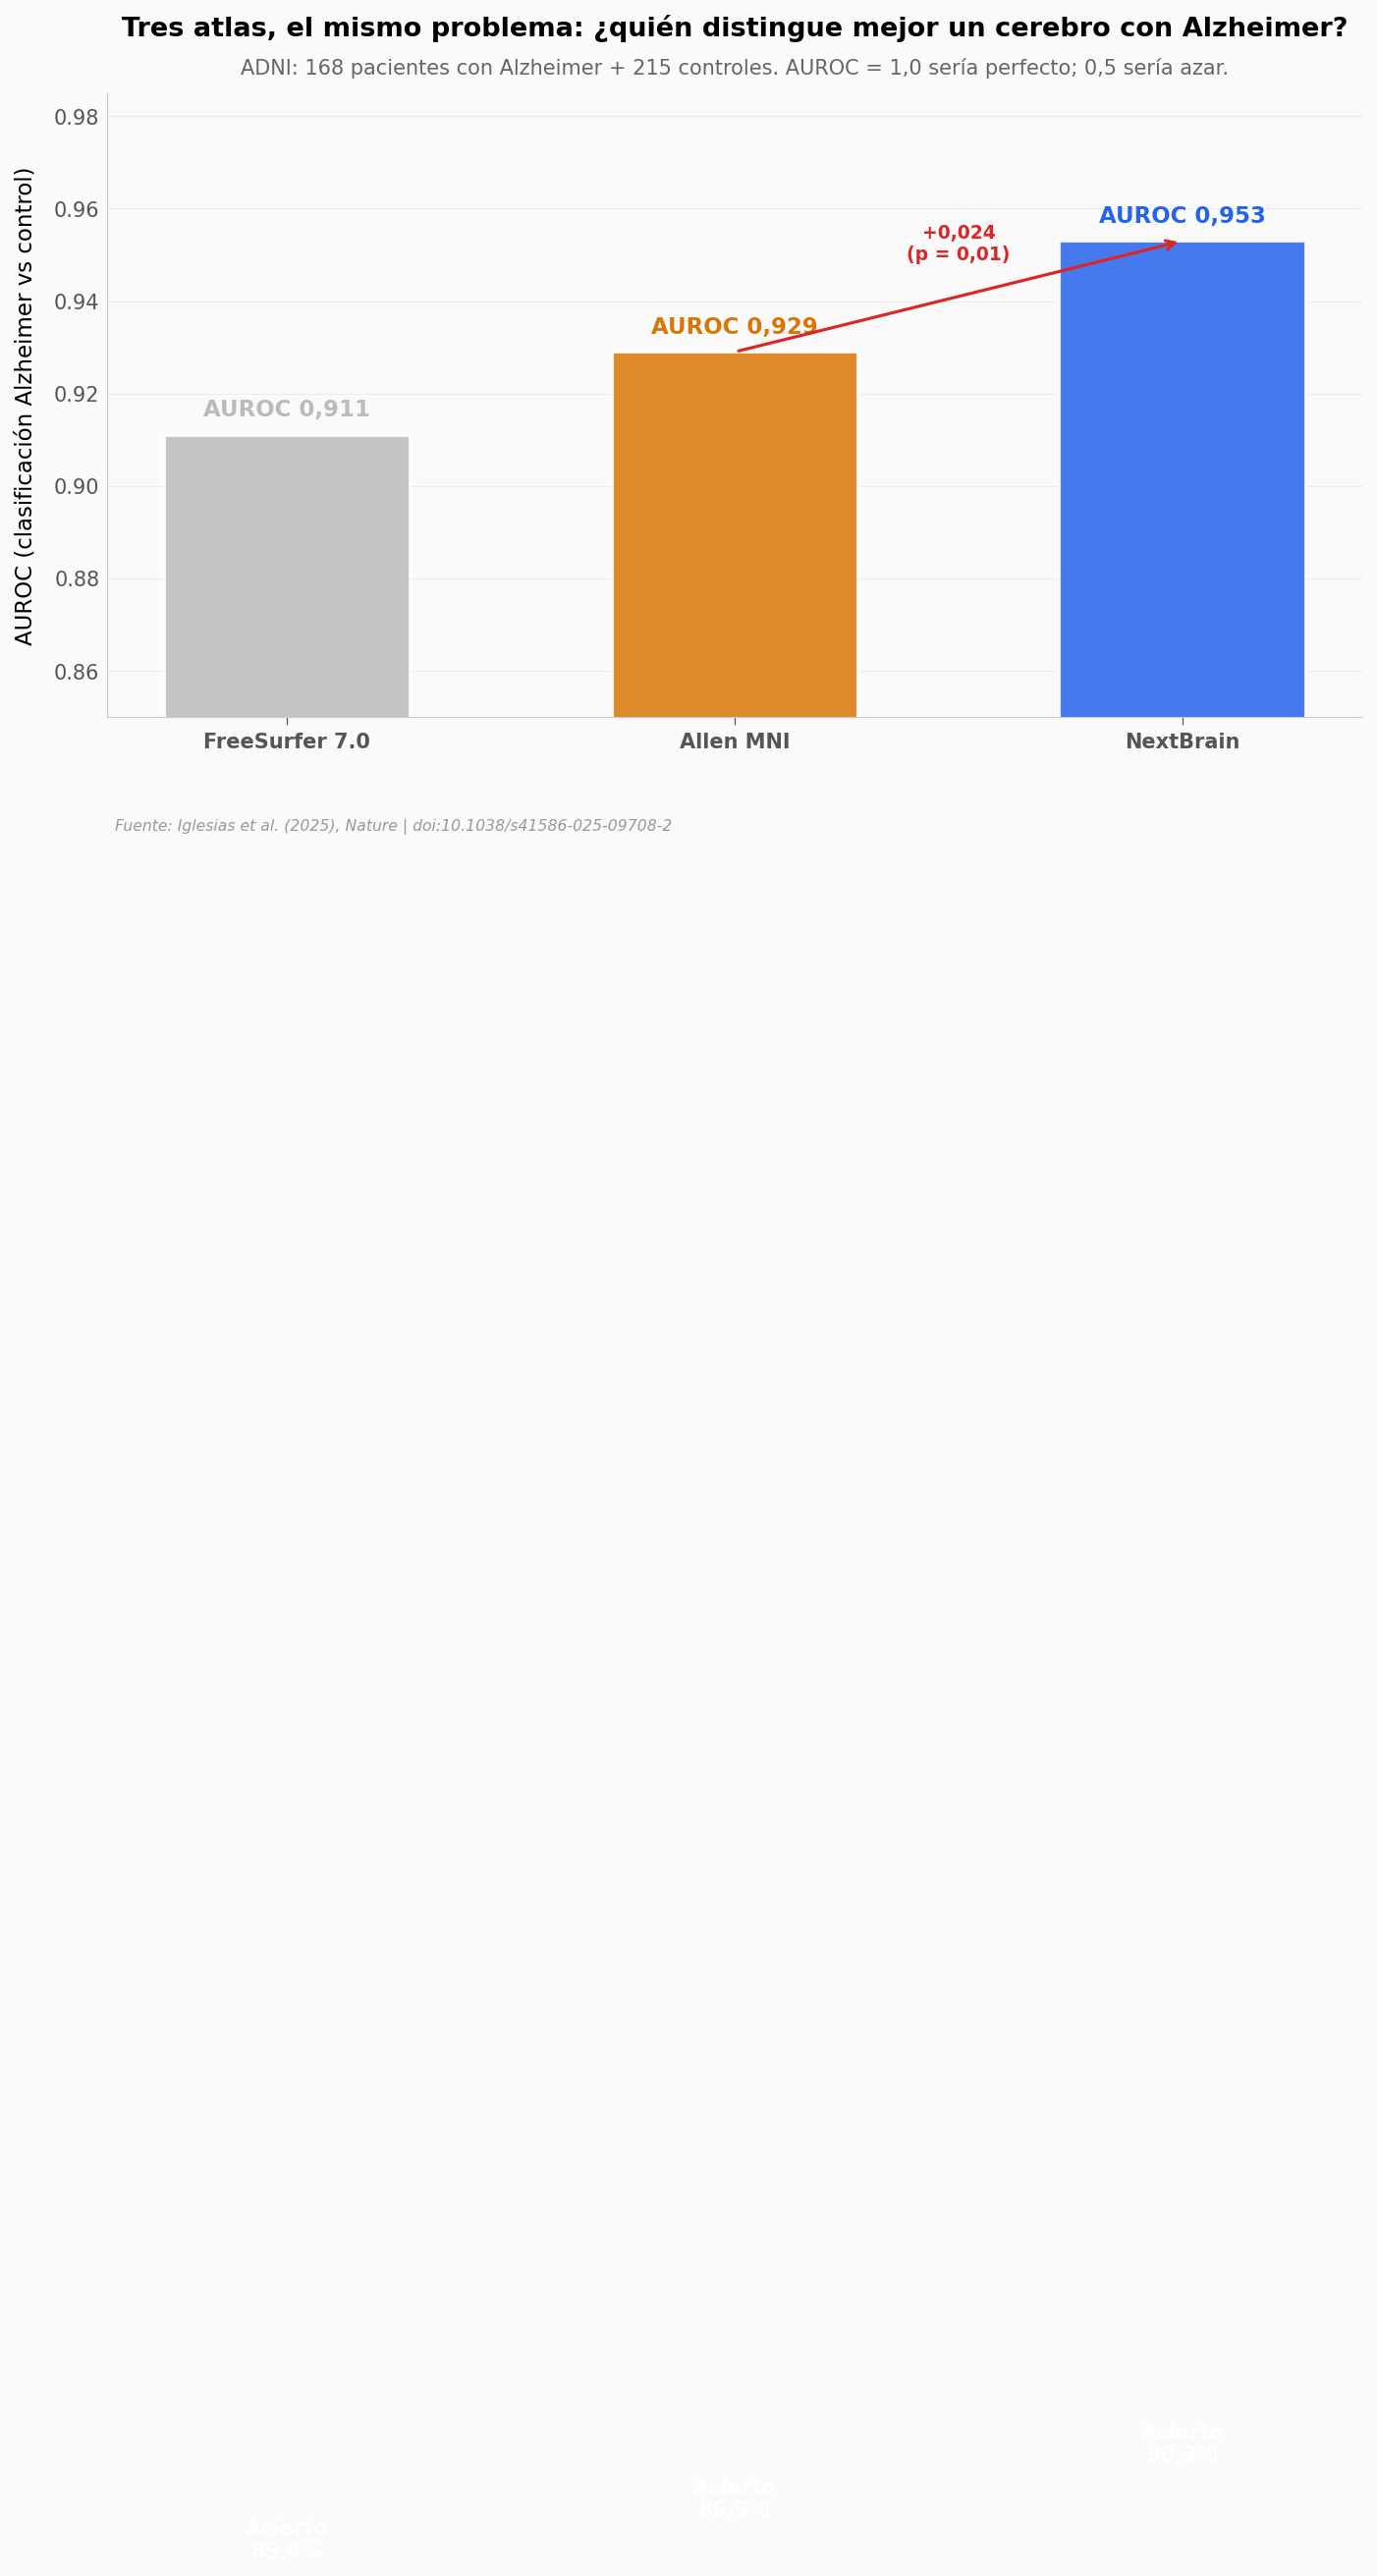

In [3]:
# Comparacion de 3 metodos en clasificacion AD vs control (ADNI n=383)
fig, ax = plt.subplots(figsize=(11, 5.5))

metodos = auroc['metodo'].tolist()
aurocs = auroc['auroc'].values
accs = auroc['accuracy_pct'].values
colores = [COLOR_PREVIO, COLOR_REFERENCIA, COLOR_NUEVO]

x_pos = np.arange(len(metodos))
bars = ax.bar(x_pos, aurocs, color=colores, alpha=0.85,
              edgecolor='white', linewidth=1.5, zorder=3, width=0.55)

# Etiquetas de AUROC sobre cada barra
for i, (a, acc) in enumerate(zip(aurocs, accs)):
    ax.text(i, a + 0.003, f'AUROC {a:.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color=colores[i])
    ax.text(i, a / 2, f'Acierto\n{acc:.1f}%'.replace('.', ','),
            ha='center', va='center', fontsize=10, color='white',
            fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(metodos, fontsize=10, fontweight='bold')
ax.set_ylabel('AUROC (clasificación Alzheimer vs control)', fontsize=11)
ax.set_ylim(0.85, 0.985)

ax.set_title('Tres atlas, el mismo problema: ¿quién distingue mejor un cerebro con Alzheimer?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'ADNI: 168 pacientes con Alzheimer + 215 controles. AUROC = 1,0 sería perfecto; 0,5 sería azar.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotacion de la diferencia clave
ax.annotate('', xy=(2, 0.953), xytext=(1, 0.929),
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.text(1.5, 0.948, '+0,024\n(p = 0,01)', ha='center', va='bottom',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/auroc_alzheimer.png', dpi=200, bbox_inches='tight')
plt.show()

**Cuidado con la lectura.** Un AUROC de 0,953 no significa "diagnostica Alzheimer al 95%". Significa que, si tomas un cerebro al azar de cada grupo, NextBrain los ordena correctamente el 95% de las veces. La precisión de clasificación binaria queda en 90,3% — alrededor de un error cada diez casos cuando los grupos son comparables.

El salto sobre Allen MNI (de 0,929 a 0,953) es modesto en valor absoluto pero estadísticamente significativo (test de DeLong, p = 0,01). Sobre FreeSurfer, la mejora es de casi 5 puntos porcentuales en acierto.

Hay una segunda métrica que ayuda a entender por qué: cuán precisa es la segmentación misma.

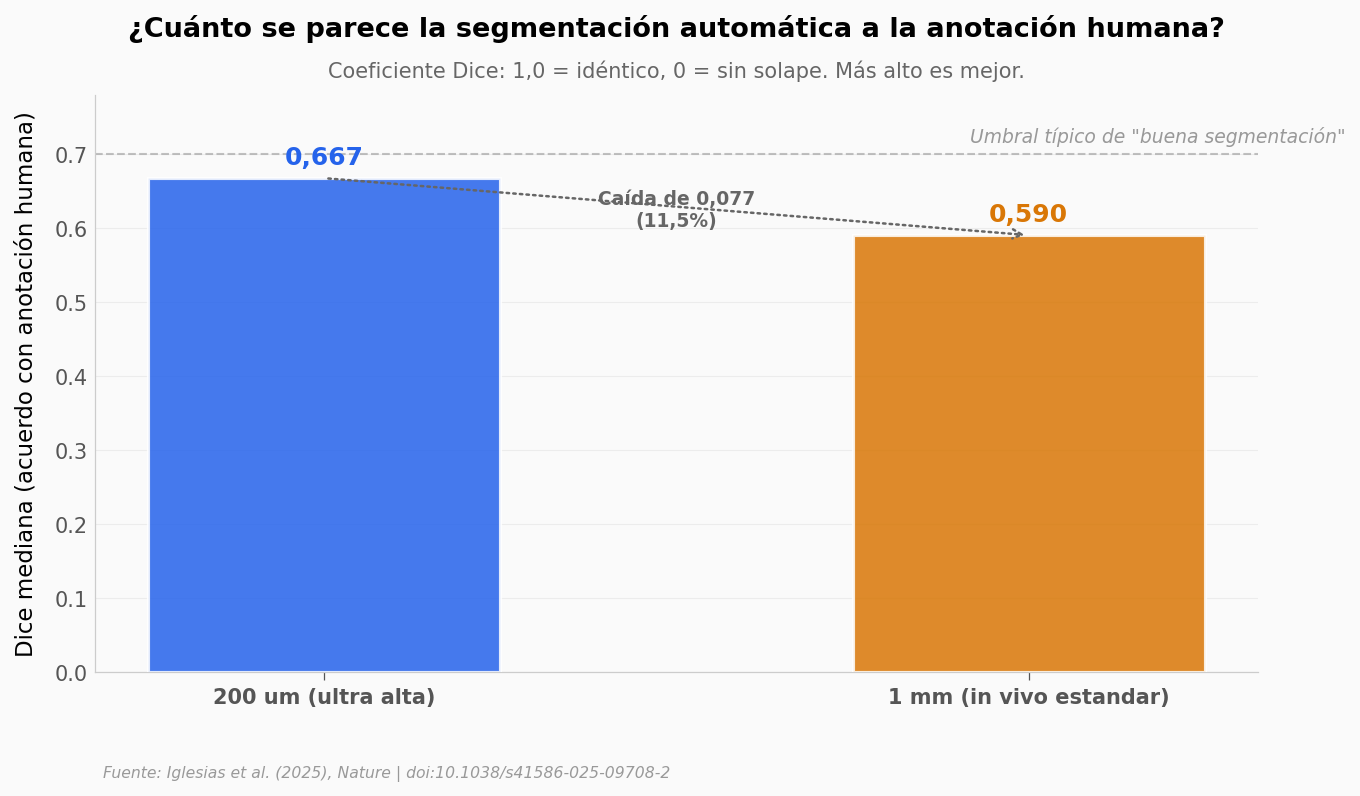

In [4]:
# Dice mediana por resolucion: ex vivo ultra alta vs in vivo estandar
fig, ax = plt.subplots(figsize=(10, 5))

reso = dice['resolucion'].tolist()
dvals = dice['dice_mediana'].values

x_pos = np.arange(len(reso))
colores_d = [COLOR_NUEVO, COLOR_REFERENCIA]
bars = ax.bar(x_pos, dvals, color=colores_d, alpha=0.85,
              edgecolor='white', linewidth=1.5, zorder=3, width=0.5)

for i, d in enumerate(dvals):
    ax.text(i, d + 0.012, f'{d:.3f}'.replace('.', ','),
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            color=colores_d[i])

ax.set_xticks(x_pos)
ax.set_xticklabels(reso, fontsize=10, fontweight='bold')
ax.set_ylabel('Dice mediana (acuerdo con anotación humana)', fontsize=11)
ax.set_ylim(0, 0.78)

ax.axhline(y=0.7, color='#999999', linewidth=1, linestyle='--', alpha=0.6)
ax.text(1.45, 0.71, 'Umbral típico de "buena segmentación"',
        fontsize=9, color='#999999', va='bottom', ha='right', style='italic')

ax.set_title('¿Cuánto se parece la segmentación automática a la anotación humana?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Coeficiente Dice: 1,0 = idéntico, 0 = sin solape. Más alto es mejor.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotacion de la caida por resolucion
ax.annotate('', xy=(1, 0.59), xytext=(0, 0.667),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2, linestyle=':'))
ax.text(0.5, 0.625, 'Caída de 0,077\n(11,5%)', ha='center', va='center',
        fontsize=9, color='#666666', fontweight='bold')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dice_resolucion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuán consistente fue la mejora?

La mejora del 31% es la media. Pero ¿qué tan parejo es el efecto entre hemisferios? Veamos la reducción de error caso por caso.

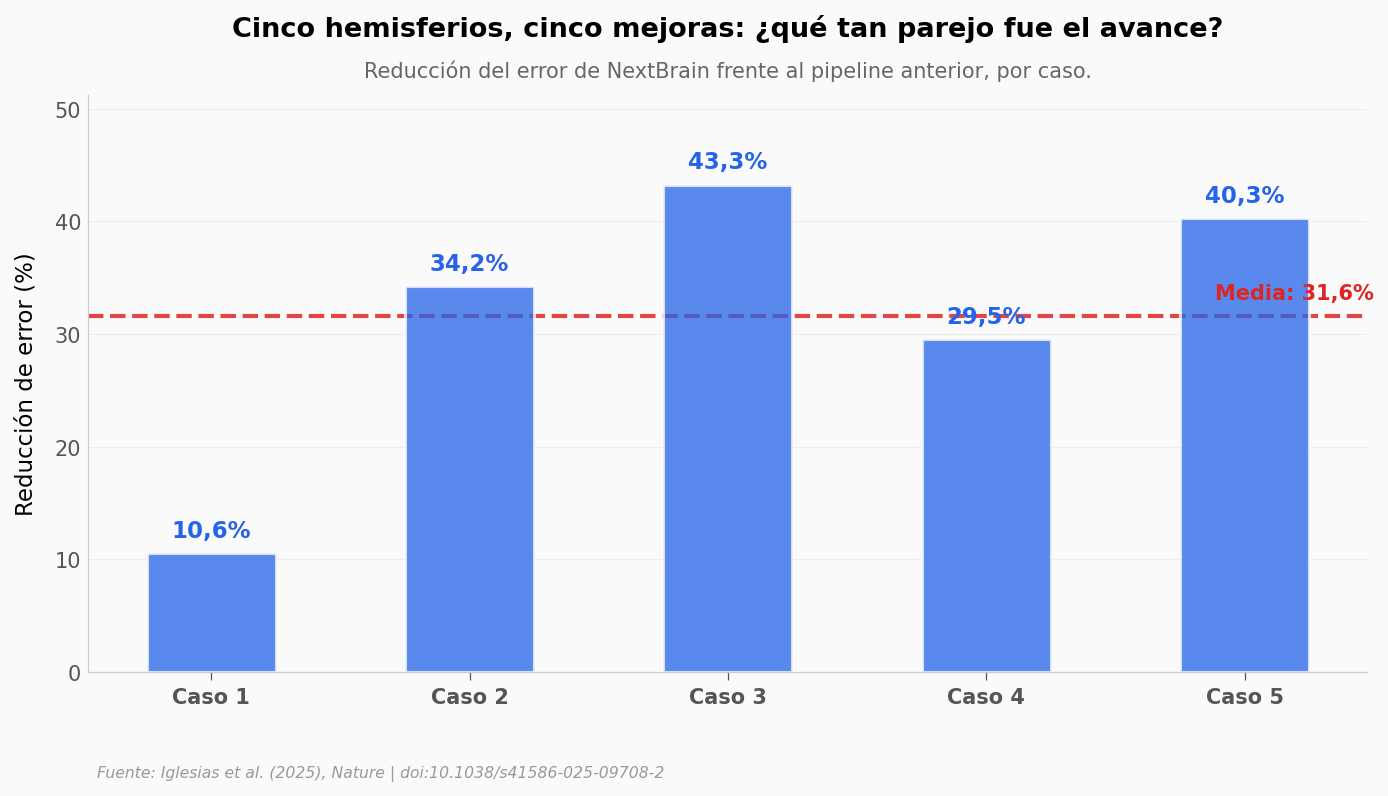

Reduccion media: 31.6%
Reduccion minima: 10.6% (Caso 1)
Reduccion maxima: 43.3% (Caso 3)
Casos con mejora: 5 de 5

Cohen d pareado (n=5 casos): 2.51 -- efecto grande (>0,8)


In [5]:
# Cierre: % reduccion de error por caso (5 hemisferios)
# Regla 6 excepcion benchmark: <20 entidades discretas, sustituimos histograma
# por scatter comparativo con linea de referencia (media)
fig, ax = plt.subplots(figsize=(11, 5))

reduccion_pct = (1 - err_nueva / err_previa) * 100
media_red = reduccion_pct.mean()
x_casos = np.arange(len(casos))

bars = ax.bar(x_casos, reduccion_pct, color=COLOR_NUEVO, alpha=0.75,
              edgecolor='white', linewidth=1.5, zorder=3, width=0.5)

for i, r in enumerate(reduccion_pct):
    ax.text(i, r + 1, f'{r:.1f}%'.replace('.', ','),
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color=COLOR_NUEVO)

ax.axhline(y=media_red, color=COLOR_ALERTA, linewidth=2, linestyle='--', alpha=0.85)
ax.text(len(casos) - 0.5, media_red + 1.5, f'Media: {media_red:.1f}%'.replace('.', ','),
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='right')

ax.set_xticks(x_casos)
ax.set_xticklabels(casos, fontsize=10, fontweight='bold')
ax.set_ylabel('Reducción de error (%)', fontsize=11)
ax.set_ylim(0, max(reduccion_pct.max() + 8, 50))

ax.set_title('Cinco hemisferios, cinco mejoras: ¿qué tan parejo fue el avance?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Reducción del error de NextBrain frente al pipeline anterior, por caso.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/reduccion_por_caso.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen cuantitativo
print(f'Reduccion media: {reduccion_pct.mean():.1f}%')
print(f'Reduccion minima: {reduccion_pct.min():.1f}% (Caso {casos[reduccion_pct.argmin()].split()[-1]})')
print(f'Reduccion maxima: {reduccion_pct.max():.1f}% (Caso {casos[reduccion_pct.argmax()].split()[-1]})')
print(f'Casos con mejora: {(reduccion_pct > 0).sum()} de {len(casos)}')

# Cohen's d pareado (sobre las 5 medias-por-caso)
diffs = err_previa - err_nueva  # positivo = mejora
d_pareado = diffs.mean() / diffs.std(ddof=1)
print(f'\nCohen d pareado (n=5 casos): {d_pareado:.2f} -- efecto grande (>0,8)')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El error de registro baja un 31% (de 1,44 a 0,99 mm de media) | ✅ | Tabla 1 del paper, n = 5 hemisferios. Cohen's d pareado = 2,51 sobre las medias-por-caso (efecto grande). Test pareado del paper: Wilcoxon sobre 250 puntos, p = 4 × 10⁻²². |
| Los 5 hemisferios mejoran consistentemente | ✅ | Reducción mínima 10,6% (Caso 1), máxima 43,3% (Caso 3). Ningún hemisferio empeora. |
| NextBrain clasifica Alzheimer mejor que FreeSurfer y Allen MNI en ADNI (n = 383) | ⚠️ | AUROC 0,953 vs 0,929 (Allen) y 0,911 (FreeSurfer). Test de DeLong NextBrain vs Allen: p = 0,01. **No es diagnóstico**: AUROC mide capacidad de ranking; el acierto binario es 90,3%, ~10% de error en discriminación. |
| Dice mediana cae al pasar de 200 µm a 1 mm de resolución | ✅ | 0,667 → 0,590, caída de 0,077 (11,5%). Esperable: a baja resolución, regiones pequeñas se vuelven indistinguibles. |
| El atlas tiene 333 ROIs (264 en versión simplificada) | ✅ | Reportado en el abstract y la sección de métodos del paper. Anotación manual, no automática. |

> **Limitaciones:**
> - n = 5 hemisferios para la validación geométrica. Es lo que está disponible cuando cada caso requiere ~10.000 secciones histológicas, pero limita la generalización a la diversidad anatómica humana.
> - Los datos crudos (≈100 GB) están en Figshare ([doi:10.5522/04/24243835](https://doi.org/10.5522/04/24243835)) pero exceden el presupuesto del entorno reproducible. Los valores graficados aquí provienen de la Tabla 1 y del texto del paper Open Access.
> - La evaluación en ADNI compara métodos sobre el mismo dataset; un test independiente requeriría replicar en otra cohorte.
> - Los hallazgos sobre envejecimiento sano (aHCP, n = 705) que el paper menciona son **correlaciones de Spearman**, no efectos causales. NextBrain detecta diferencias volumétricas asociadas a edad o enfermedad — no las causa ni las cura.

## Ahora tú

Tres preguntas para explorar con los datos cargados:

1. ¿Cuál es el caso con mayor desviación estándar dentro de cada método? Pista: agrupa por `metodo` y mira `error_mm_sd`.
2. Si calculas la mejora absoluta (mm) en lugar de porcentual, ¿se mantiene el ranking entre casos? Compara `err_previa - err_nueva` con `(err_previa - err_nueva) / err_previa`.
3. Construye una métrica simple "¿supera el umbral de 1,0 mm?" para cada caso × método. ¿Cuántos casos quedan por debajo de ese umbral con el método nuevo? ¿Y con el anterior?

In [6]:
# --- EXPERIMENTA AQUI ---
# Pregunta 3: ¿cuantos casos quedan por debajo de 1,0 mm de error medio?

UMBRAL_MM = 1.0

por_metodo = registro.groupby('metodo')['error_mm_media'].apply(
    lambda s: (s < UMBRAL_MM).sum()
)

print(f'Casos con error medio < {UMBRAL_MM} mm:')
for m in ['previa', 'nueva']:
    nombre = 'Pipeline anterior' if m == 'previa' else 'NextBrain'
    print(f'  {nombre:18s}: {por_metodo[m]} de {registro["caso"].nunique()}')

# Cambia UMBRAL_MM a 0,8 o 1,2 y vuelve a correr.

Casos con error medio < 1.0 mm:
  Pipeline anterior : 0 de 5
  NextBrain         : 3 de 5


## Fuentes

**Paper**: [A probabilistic histological atlas of the human brain for MRI segmentation](https://doi.org/10.1038/s41586-025-09708-2)  
*Nature, 2025-11-05*

**Datos crudos (~100 GB)**: [Registered histology, MRI, and manual annotations of over 300 brain regions in 5 human hemispheres (BUNGEE-TOOLS)](https://doi.org/10.5522/04/24243835)  
*UCL Research Data Repository (Figshare)*

**Fuente directa de los CSVs**: [Table 1 — Registration error per case (NextBrain vs previous pipeline)](https://www.nature.com/articles/s41586-025-09708-2/tables/1)

*24 afirmaciones verificadas contra estas fuentes*

---

**Reproducir localmente:**
```bash
pip install pandas matplotlib numpy
jupyter execute notebook.ipynb
```

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** MIT (código), CC-BY (texto)
